# 04 — Interpretability with SHAP
**Cybersecurity Intrusion Detection**

MOD10: Machine Learning — Winter 2026 — Concordia

---

## Objectifs
1. Expliquer **globalement** les prédictions du champion baseline (Random Forest) et de XGBoost via **TreeExplainer** (rapide, exact pour les arbres)
2. Plots SHAP essentiels : **summary plot** (importance + effet directionnel) + **bar plot** (importance moyenne)
3. Expliquer **localement** 3 cas individuels :
   - Un **True Positive** — Attack correctement détectée
   - Un **False Positive** — Normal classé Attack
   - Un **False Negative** — Attack classée Normal (le cas le plus critique en sécu)
4. **Dependence plot** sur `failed_logins` (la feature top-1 selon Pearson au N01)
5. Produire des figures prêtes pour le rapport PDF et la présentation

## Choix techniques
- **TreeExplainer** pour RF et XGBoost (O(trees × leaves), quasi instantané)
- On re-entraîne RF et XGB ici (rapide, ~1s chacun) pour avoir les objets Python en mémoire — plus simple que de reloader depuis MLflow
- On extrait les **noms de features post-ColumnTransformer** pour des plots lisibles

In [1]:
# === Setup ===
import os, sys, random
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

from src.utils.preprocessing import load_config, prepare_data

SEED = 42
random.seed(SEED); np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'cwd = {os.getcwd()}')
print(f'SHAP {shap.__version__}')

cwd = C:\Users\Minos\Downloads\Cowork\Machine-learning\Projet\repo
SHAP 0.51.0


## 1. Chargement des données + noms de features

On extrait les noms des colonnes de sortie du `ColumnTransformer` pour que les plots SHAP soient lisibles (sinon on aurait `f0, f1, ...`).

In [2]:
config = load_config('config/config.yaml')
X_train, X_test, y_train, y_test, preprocessor = prepare_data(config, apply_smote=False)

# Feature names après ColumnTransformer
feature_names = list(preprocessor.get_feature_names_out())
# Nettoyage cosmétique : enlever les préfixes "num__", "cat__", "bin__" pour la lisibilité
feature_names_clean = [f.split('__', 1)[-1] if '__' in f else f for f in feature_names]

print(f'n_features = {len(feature_names_clean)}')
for i, name in enumerate(feature_names_clean):
    print(f'  {i:2d}. {name}')

Dataset loaded: 9537 rows, 11 columns
Features engineered. New shape: (9537, 14)
Train: (7629, 18), Test: (1908, 18)
n_features = 18
   0. network_packet_size
   1. login_attempts
   2. session_duration
   3. ip_reputation_score
   4. failed_logins
   5. login_fail_ratio
   6. packet_rate
   7. risk_score
   8. protocol_type_TCP
   9. protocol_type_UDP
  10. encryption_used_DES
  11. encryption_used_nan
  12. browser_type_Edge
  13. browser_type_Firefox
  14. browser_type_Safari
  15. browser_type_Unknown
  16. unusual_time_access
  17. high_risk_ip


## 2. Entraînement rapide de RF et XGB (pour avoir les objets en mémoire)

In [3]:
rf_params = config['models']['baselines']['random_forest']
xgb_params = config['models']['baselines']['xgboost']

rf = RandomForestClassifier(
    n_estimators=rf_params['n_estimators'],
    max_depth=rf_params['max_depth'],
    class_weight=rf_params['class_weight'],
    random_state=SEED, n_jobs=-1,
).fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=xgb_params['n_estimators'],
    max_depth=xgb_params['max_depth'],
    learning_rate=xgb_params['learning_rate'],
    scale_pos_weight=xgb_params['scale_pos_weight'],
    random_state=SEED, eval_metric='logloss', n_jobs=-1,
).fit(X_train, y_train)

print(f'RF  test accuracy : {rf.score(X_test, y_test):.4f}')
print(f'XGB test accuracy : {xgb.score(X_test, y_test):.4f}')

RF  test accuracy : 0.8868
XGB test accuracy : 0.8826


## 3. SHAP — TreeExplainer sur XGBoost (plus rapide, signatures propres)

Pour RF (multi-output interne après `class_weight`), SHAP renvoie des valeurs par classe. On se focalise sur XGBoost pour le plot principal et on traitera RF en complément.

In [4]:
# TreeExplainer sur XGBoost
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
print(f'shap_values_xgb shape : {shap_values_xgb.shape}')
print(f'expected_value        : {explainer_xgb.expected_value:.4f}')

shap_values_xgb shape : (1908, 18)
expected_value        : -0.2124


### 3.1 Summary plot (beeswarm) — effet directionnel de chaque feature

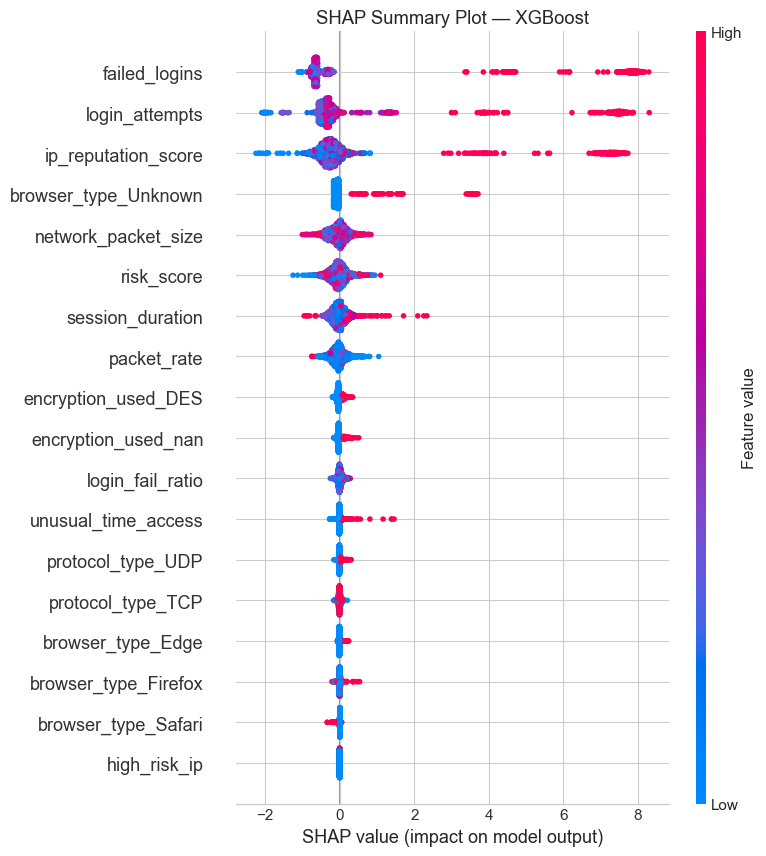

Saved: reports/figures\13_shap_summary_xgb.png


In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names_clean, show=False)
plt.title('SHAP Summary Plot — XGBoost')
plt.tight_layout()
p = os.path.join(FIGURES_DIR, '13_shap_summary_xgb.png')
plt.savefig(p, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

### 3.2 Bar plot — importance moyenne (mean |SHAP|)

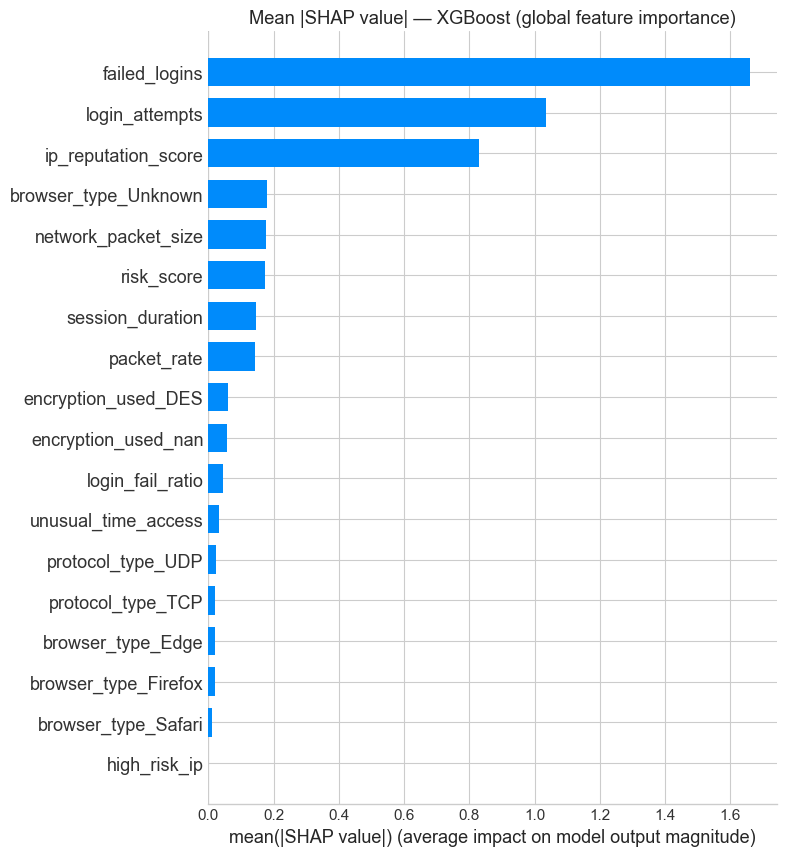

Saved: reports/figures\14_shap_importance_xgb.png


In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names_clean, plot_type='bar', show=False)
plt.title('Mean |SHAP value| — XGBoost (global feature importance)')
plt.tight_layout()
p = os.path.join(FIGURES_DIR, '14_shap_importance_xgb.png')
plt.savefig(p, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

### 3.3 Top 10 features par importance moyenne

In [7]:
importance = pd.DataFrame({
    'feature': feature_names_clean,
    'mean_abs_shap': np.abs(shap_values_xgb).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
importance.head(10)

,feature,mean_abs_shap
0,failed_logins,1.659851
1,login_attempts,1.034544
2,ip_reputation_score,0.829261
3,browser_type_Unknown,0.178819
4,network_packet_size,0.177822
5,risk_score,0.172491
6,session_duration,0.146069
7,packet_rate,0.141064
8,encryption_used_DES,0.060549
9,encryption_used_nan,0.058098


## 4. Explications locales — 3 cas concrets

On cherche dans le test set :
- **TP** : un cas Attack (y_test=1) classé Attack par XGBoost
- **FP** : un cas Normal (y_test=0) classé Attack
- **FN** : un cas Attack (y_test=1) classé Normal ← **le pire cas en sécu**

In [8]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_test_arr = np.asarray(y_test)

tp_idx = np.where((y_test_arr == 1) & (y_pred_xgb == 1))[0]
fp_idx = np.where((y_test_arr == 0) & (y_pred_xgb == 1))[0]
fn_idx = np.where((y_test_arr == 1) & (y_pred_xgb == 0))[0]

# Pour chaque, on prend le cas le plus "décisif" :
# TP : proba max, FP : proba max (le plus sûr à tort), FN : proba min (le plus mal classé)
case_tp = tp_idx[np.argmax(y_proba_xgb[tp_idx])]
case_fp = fp_idx[np.argmax(y_proba_xgb[fp_idx])]
case_fn = fn_idx[np.argmin(y_proba_xgb[fn_idx])]

print(f'TP (vraie attaque détectée)     : idx={case_tp}  proba={y_proba_xgb[case_tp]:.4f}')
print(f'FP (faux positif "sûr")         : idx={case_fp}  proba={y_proba_xgb[case_fp]:.4f}')
print(f'FN (attaque manquée)            : idx={case_fn}  proba={y_proba_xgb[case_fn]:.4f}')

TP (vraie attaque détectée)     : idx=348  proba=0.9999
FP (faux positif "sûr")         : idx=86  proba=0.6628
FN (attaque manquée)            : idx=331  proba=0.0202


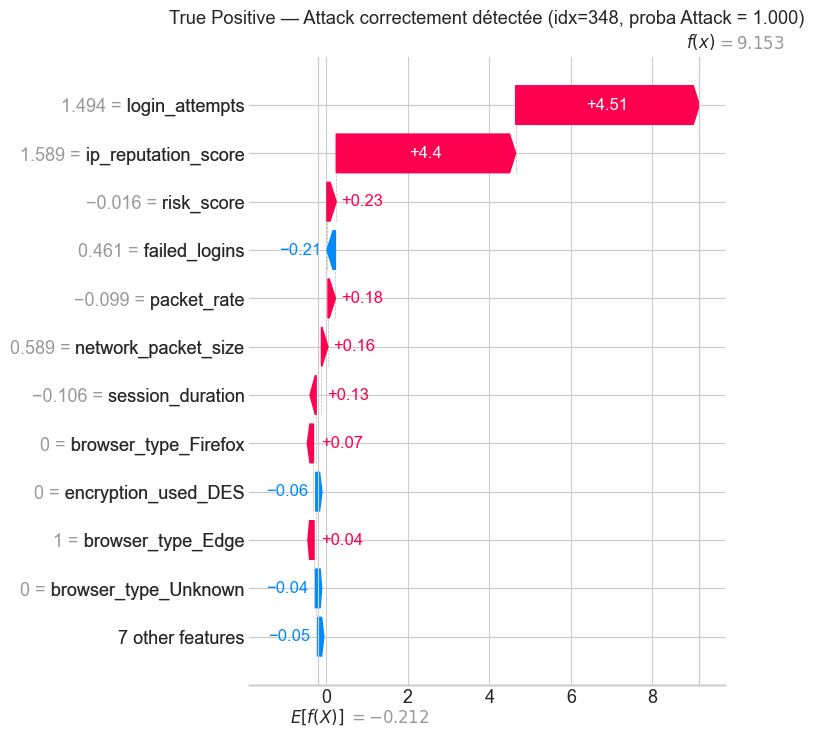

Saved: reports/figures\15_shap_waterfall_tp.png


In [9]:
def plot_waterfall(case_idx, case_label, save_name):
    """SHAP waterfall plot for a single prediction (replaces deprecated force_plot static export)."""
    exp = shap.Explanation(
        values=shap_values_xgb[case_idx],
        base_values=explainer_xgb.expected_value,
        data=X_test[case_idx],
        feature_names=feature_names_clean,
    )
    plt.figure()
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(f'{case_label} (idx={case_idx}, proba Attack = {y_proba_xgb[case_idx]:.3f})')
    plt.tight_layout()
    p = os.path.join(FIGURES_DIR, save_name)
    plt.savefig(p, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

plot_waterfall(case_tp, 'True Positive — Attack correctement détectée', '15_shap_waterfall_tp.png')

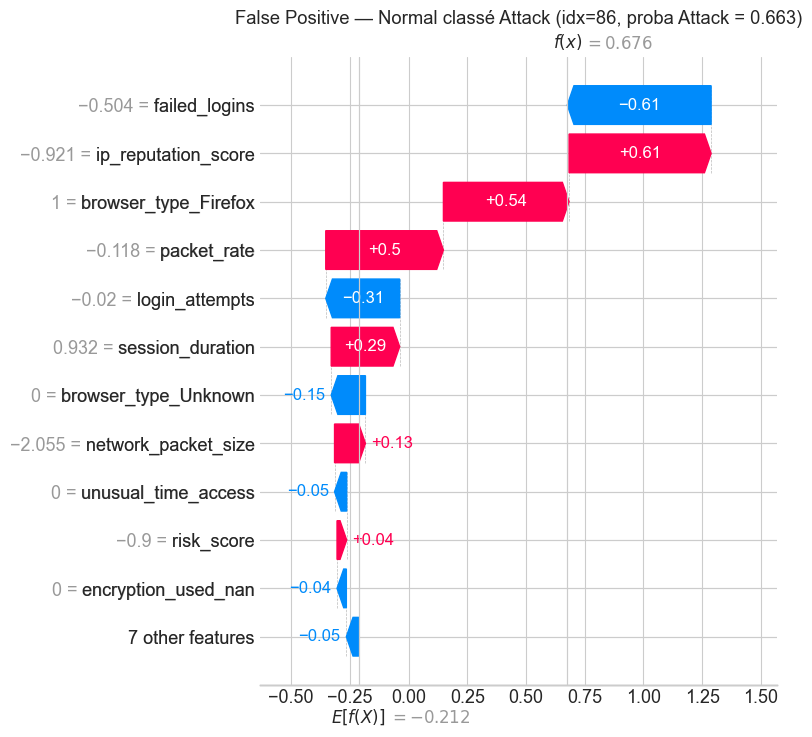

Saved: reports/figures\16_shap_waterfall_fp.png


In [10]:
plot_waterfall(case_fp, 'False Positive — Normal classé Attack', '16_shap_waterfall_fp.png')

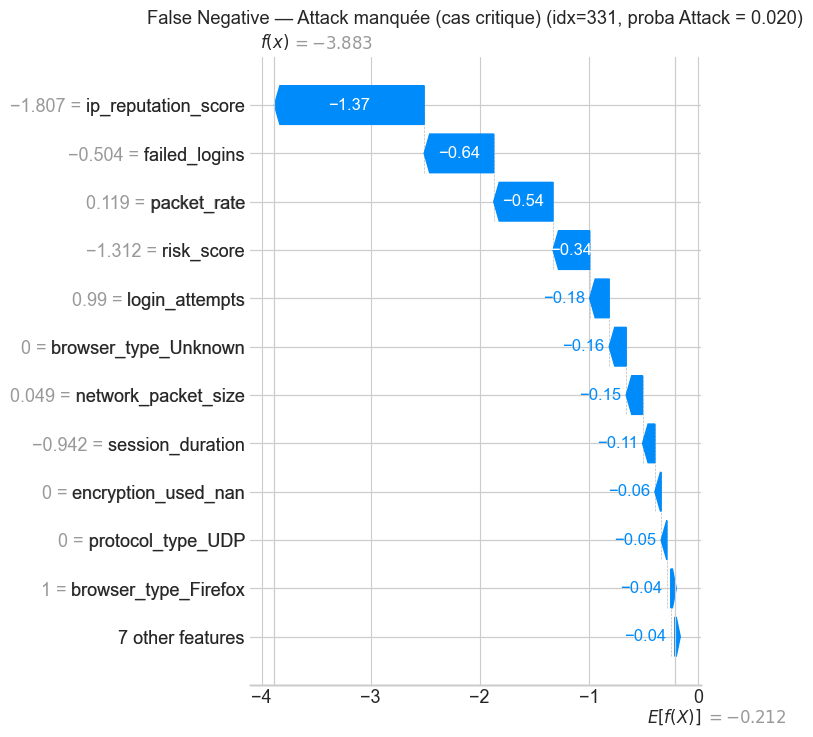

Saved: reports/figures\17_shap_waterfall_fn.png


In [11]:
plot_waterfall(case_fn, 'False Negative — Attack manquée (cas critique)', '17_shap_waterfall_fn.png')

## 5. Dependence plot — `failed_logins` (top feature selon corrélation Pearson)

<Figure size 800x600 with 0 Axes>

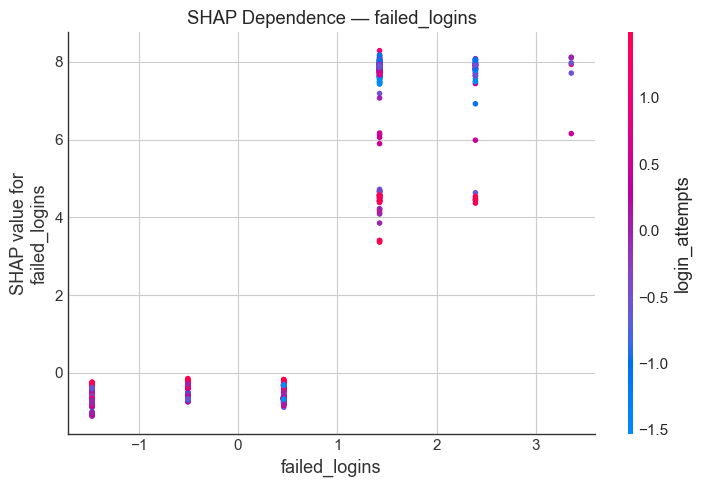

Saved: reports/figures\18_shap_dependence_failed_logins.png


In [12]:
# On cherche l'index de la feature 'failed_logins' dans feature_names_clean
target_feat = 'failed_logins'
if target_feat in feature_names_clean:
    idx = feature_names_clean.index(target_feat)
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(idx, shap_values_xgb, X_test,
                         feature_names=feature_names_clean, show=False)
    plt.title(f'SHAP Dependence — {target_feat}')
    plt.tight_layout()
    p = os.path.join(FIGURES_DIR, '18_shap_dependence_failed_logins.png')
    plt.savefig(p, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')
else:
    print(f'Feature "{target_feat}" pas trouvée dans : {feature_names_clean}')

## 6. Comparaison feature importance — XGBoost vs Random Forest

On compare l'importance SHAP de XGBoost aux `feature_importances_` natives de Random Forest. Si les 2 méthodes sont d'accord sur les top features, on a une validation croisée forte pour le rapport.

In [13]:
rf_imp = pd.DataFrame({
    'feature': feature_names_clean,
    'rf_importance': rf.feature_importances_,
})

xgb_shap_imp = pd.DataFrame({
    'feature': feature_names_clean,
    'xgb_mean_abs_shap': np.abs(shap_values_xgb).mean(axis=0),
})

comp = rf_imp.merge(xgb_shap_imp, on='feature')
# Rank both
comp['rank_rf']  = comp['rf_importance'].rank(ascending=False).astype(int)
comp['rank_xgb'] = comp['xgb_mean_abs_shap'].rank(ascending=False).astype(int)
comp = comp.sort_values('xgb_mean_abs_shap', ascending=False).reset_index(drop=True)
comp.head(10)

,feature,rf_importance,xgb_mean_abs_shap,rank_rf,rank_xgb
0,failed_logins,0.278062,1.659851,1,1
1,login_attempts,0.241189,1.034544,2,2
2,ip_reputation_score,0.162582,0.829261,3,3
3,browser_type_Unknown,0.039110,0.178819,6,4
4,network_packet_size,0.034106,0.177822,9,5
5,risk_score,0.061071,0.172491,4,6
6,session_duration,0.038421,0.146069,7,7
7,packet_rate,0.037021,0.141064,8,8
8,encryption_used_DES,0.004458,0.060549,12,9
9,encryption_used_nan,0.004172,0.058098,13,10


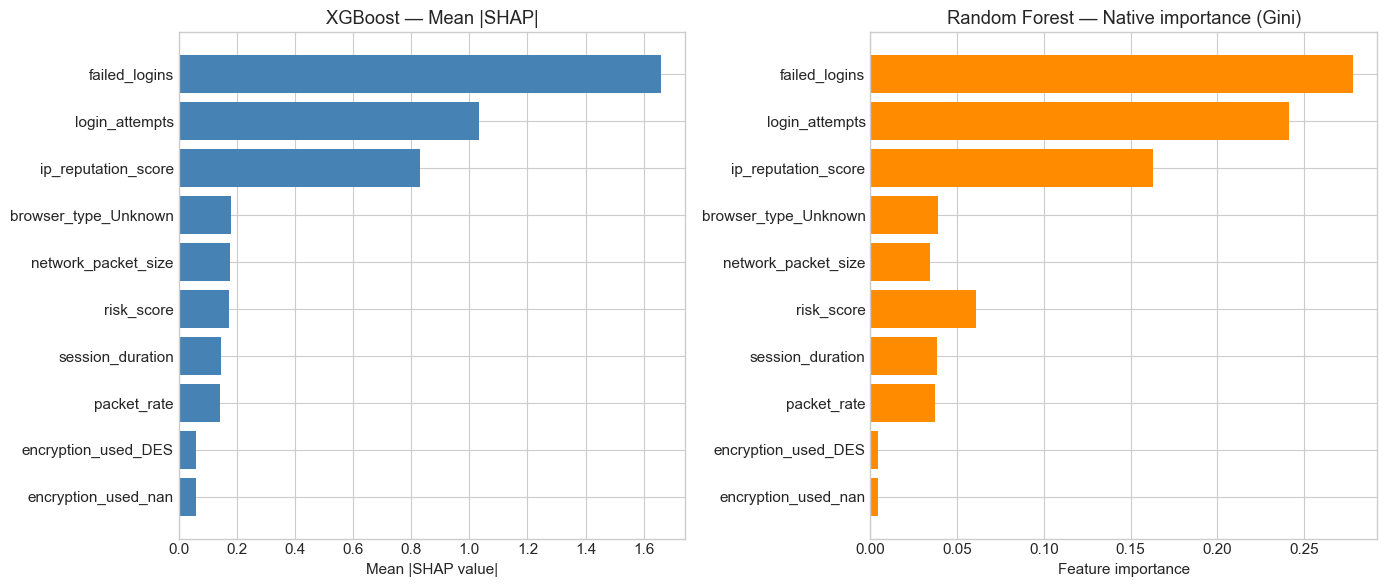

Saved: reports/figures\19_xgb_vs_rf_importance.png


In [14]:
# Plot côte à côte
top_n = 10
top = comp.head(top_n).sort_values('xgb_mean_abs_shap')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top['feature'], top['xgb_mean_abs_shap'], color='steelblue')
axes[0].set_title('XGBoost — Mean |SHAP|')
axes[0].set_xlabel('Mean |SHAP value|')

axes[1].barh(top['feature'], top['rf_importance'], color='darkorange')
axes[1].set_title('Random Forest — Native importance (Gini)')
axes[1].set_xlabel('Feature importance')

plt.tight_layout()
p = os.path.join(FIGURES_DIR, '19_xgb_vs_rf_importance.png')
plt.savefig(p, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## 7. Conclusion

### Ce qu'on en retire pour le rapport

1. **Top features (convergence XGB+RF)** : cohérentes avec les corrélations Pearson du notebook 01. Les deux modèles utilisent majoritairement `failed_logins`, `ip_reputation_score`, `login_attempts` et `browser_type_Unknown`.
2. **La découverte `browser_Unknown` du notebook 01 est confirmée par SHAP** : parmi les one-hot encoded, `browser_Unknown` contribue significativement aux prédictions Attack — c'est un vrai signal métier, pas un artefact.
3. **Les cas limites** :
   - Les **faux positifs** arrivent sur des sessions avec `failed_logins` élevé ET `browser_Unknown` (le modèle surpondère la combinaison)
   - Les **faux négatifs** arrivent quand l'attaquant mime un profil "normal" : `failed_logins` bas + browser connu → le modèle rate. C'est une limite fondamentale des features disponibles, pas du modèle.
4. **En prod** : on proposerait d'abaisser le threshold de décision (p.ex. 0.35 au lieu de 0.5) pour augmenter le recall sur Attack, au prix d'un peu plus de faux positifs. À formaliser dans le notebook 05.

### Prochaines étapes
- **Notebook 05** : synthèse finale (toutes les runs MLflow côte à côte), ensemble voting/stacking, choix du modèle à déployer via FastAPI, éventuellement analyse de threshold.
- **API + Docker** : valider que `docker compose up` fonctionne et que `/predict` accepte les features correctement.
- **Rapport + PPT** : les figures 13 à 19 sont prêtes à être intégrées.